<a href="https://colab.research.google.com/github/DanushVikraman007/Capstone_share/blob/Benchmark/test_benchmark_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


STEP 1: DATA ACQUISITION

Fetching data for 20 stocks from 2023-10-03 to 2025-10-02...
Successfully fetched 502 days of data for 20 stocks

Expected annual returns range: -9.28% to 86.93%
Risk-free rate: 4.00%

STEP 2: OBJECTIVE FUNCTION SETUP

Objective: Minimize Negative Sharpe Ratio
Constraints: Weights sum to 1, each ≥ 0, max per asset = 20.0%

STEP 3: YO HYBRID OPTIMIZATION


YO HYBRID OPTIMIZER - Portfolio Optimization
Assets: 20 | Chains: 4 | Iterations: 500

Chain 1: Starting optimization...
Chain 1: MCMC complete. Best score: -2.008158
Chain 1: Improved via SA to -2.373738
Chain 2: Starting optimization...
Chain 2: MCMC complete. Best score: -2.030406
Chain 2: Improved via SA to -2.373498
Chain 2: Improved via SA to -2.373682
Chain 3: Starting optimization...
Chain 3: MCMC complete. Best score: -2.139141
Chain 3: Improved via SA to -2.373750
Chain 4: Starting optimization...
Chain 4: MCMC complete. Best score: -1.979312
Chain 4: Improved via SA to -2.373714

OPTIMIZATION COMP

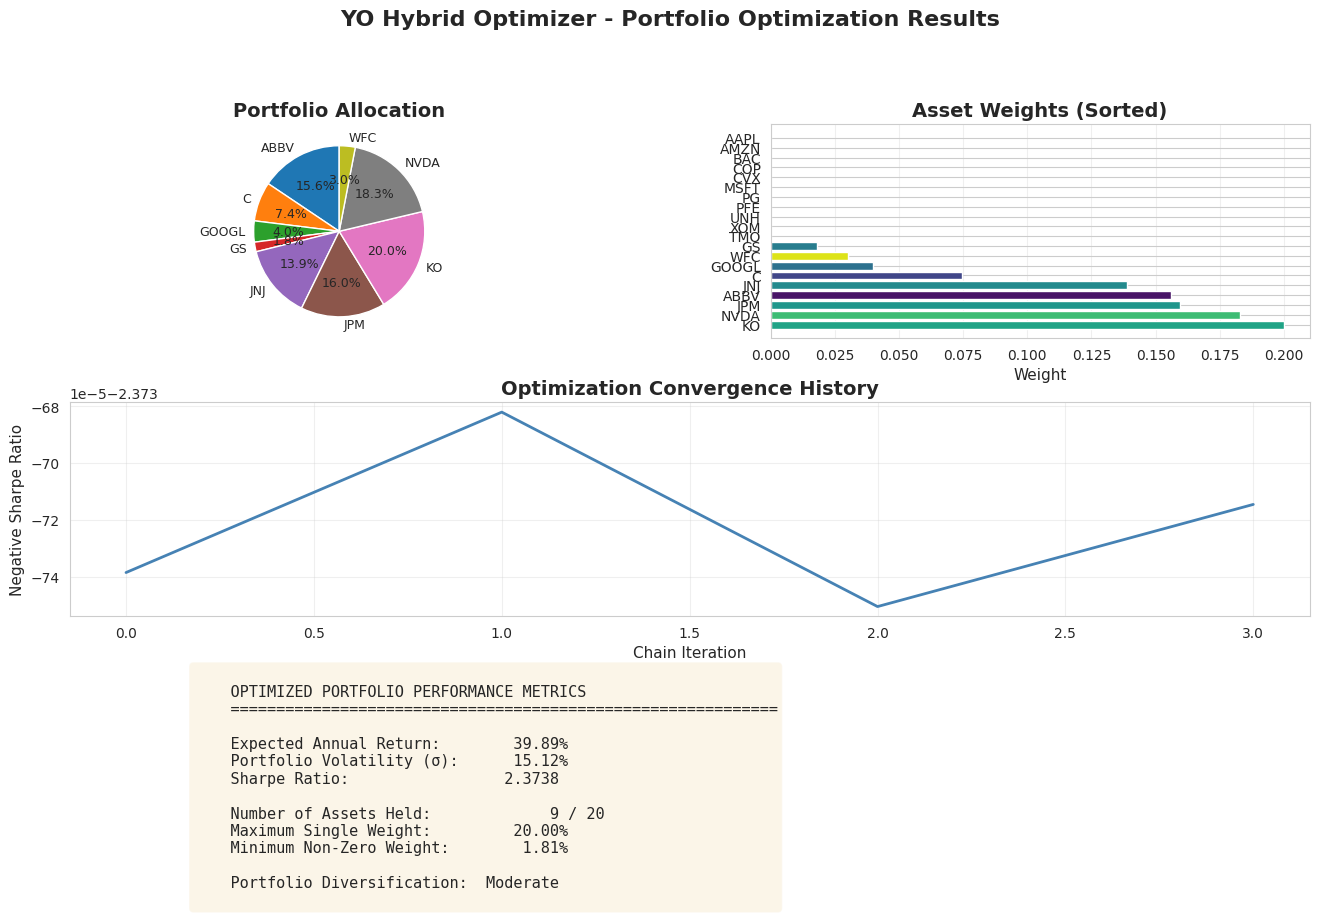


OPTIMIZATION COMPLETE!



In [2]:
"""
YO Hybrid Optimizer for Portfolio Optimization
===============================================
A three-layer optimization framework combining:
- MCMC for global exploration
- Greedy search for local exploitation
- Simulated Annealing with adaptive reheating
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from typing import Tuple, List, Callable
import warnings
warnings.filterwarnings('ignore')

# For data fetching
try:
    import yfinance as yf
except ImportError:
    print("Installing yfinance...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'yfinance', '-q'])
    import yfinance as yf

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# ============================================================================
# DATA ACQUISITION AND PREPROCESSING
# ============================================================================

def fetch_stock_data(tickers: List[str], years: int = 2) -> pd.DataFrame:
    """
    Fetch historical stock prices from Yahoo Finance.

    Args:
        tickers: List of stock ticker symbols
        years: Number of years of historical data

    Returns:
        DataFrame with adjusted close prices
    """
    end_date = datetime.now()
    start_date = end_date - timedelta(days=years*365)

    print(f"Fetching data for {len(tickers)} stocks from {start_date.date()} to {end_date.date()}...")

    # Download data
    raw_data = yf.download(tickers, start=start_date, end=end_date, progress=False)

    # Handle different return structures
    if isinstance(raw_data, pd.Series):
        # Single ticker, single column
        data = raw_data.to_frame()
        data.columns = [tickers[0]]
    elif isinstance(raw_data.columns, pd.MultiIndex):
        # Multiple tickers - extract 'Adj Close' from MultiIndex
        if 'Adj Close' in raw_data.columns.get_level_values(0):
            data = raw_data['Adj Close']
        else:
            # Fallback to 'Close' if 'Adj Close' not available
            data = raw_data['Close']
    else:
        # Single ticker case where columns are not MultiIndex
        if 'Adj Close' in raw_data.columns:
            data = raw_data[['Adj Close']]
            data.columns = [tickers[0]]
        else:
            data = raw_data[['Close']]
            data.columns = [tickers[0]]

    # Ensure data is DataFrame
    if isinstance(data, pd.Series):
        data = data.to_frame()

    # Remove stocks with too much missing data
    missing_pct = data.isnull().sum() / len(data)
    valid_tickers = missing_pct[missing_pct < 0.1].index.tolist()

    if len(valid_tickers) < len(tickers):
        print(f"Removed {len(tickers) - len(valid_tickers)} stocks due to missing data")

    data = data[valid_tickers].dropna()
    print(f"Successfully fetched {len(data)} days of data for {len(valid_tickers)} stocks")

    return data

def compute_portfolio_metrics(prices: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, float]:
    """
    Compute expected returns, covariance matrix, and risk-free rate.

    Args:
        prices: DataFrame of stock prices

    Returns:
        Tuple of (expected_returns, covariance_matrix, risk_free_rate)
    """
    # Calculate daily returns
    returns = prices.pct_change().dropna()

    # Annualize returns (252 trading days)
    expected_returns = returns.mean().values * 252

    # Annualize covariance
    cov_matrix = returns.cov().values * 252

    # Risk-free rate (approximate 10-year Treasury rate)
    risk_free_rate = 0.04

    return expected_returns, cov_matrix, risk_free_rate

# ============================================================================
# PORTFOLIO OPTIMIZATION OBJECTIVE FUNCTION
# ============================================================================

class PortfolioObjective:
    """Objective function for portfolio optimization (minimize negative Sharpe ratio)."""

    def __init__(self, expected_returns: np.ndarray, cov_matrix: np.ndarray,
                 risk_free_rate: float, max_weight: float = 0.2):
        self.expected_returns = expected_returns
        self.cov_matrix = cov_matrix
        self.risk_free_rate = risk_free_rate
        self.max_weight = max_weight
        self.n_assets = len(expected_returns)

    def __call__(self, weights: np.ndarray) -> float:
        """
        Calculate negative Sharpe ratio (to minimize).

        Args:
            weights: Portfolio weights (must sum to 1)

        Returns:
            Negative Sharpe ratio (lower is better)
        """
        # Ensure weights are valid
        weights = np.clip(weights, 0, self.max_weight)
        weights = weights / weights.sum()  # Normalize

        # Portfolio return
        portfolio_return = np.dot(weights, self.expected_returns)

        # Portfolio volatility
        portfolio_variance = np.dot(weights, np.dot(self.cov_matrix, weights))
        portfolio_std = np.sqrt(portfolio_variance)

        # Sharpe ratio
        if portfolio_std < 1e-10:
            return 1e10  # Penalty for zero volatility

        sharpe_ratio = (portfolio_return - self.risk_free_rate) / portfolio_std

        return -sharpe_ratio  # Minimize negative Sharpe

    def get_portfolio_stats(self, weights: np.ndarray) -> dict:
        """Get detailed portfolio statistics."""
        weights = np.clip(weights, 0, self.max_weight)
        weights = weights / weights.sum()

        portfolio_return = np.dot(weights, self.expected_returns)
        portfolio_variance = np.dot(weights, np.dot(self.cov_matrix, weights))
        portfolio_std = np.sqrt(portfolio_variance)
        sharpe_ratio = (portfolio_return - self.risk_free_rate) / portfolio_std

        return {
            'weights': weights,
            'return': portfolio_return,
            'volatility': portfolio_std,
            'sharpe_ratio': sharpe_ratio
        }

# ============================================================================
# YO HYBRID OPTIMIZER IMPLEMENTATION
# ============================================================================

class YOHybridOptimizer:
    """
    YO Hybrid Optimizer: Three-layer optimization framework.

    Layers:
    1. MCMC for global exploration
    2. Greedy search for local exploitation
    3. Simulated Annealing with adaptive reheating
    """

    def __init__(self, objective_fn: Callable, n_assets: int, max_weight: float = 0.2,
                 n_chains: int = 4, burnin: int = 100, n_iterations: int = 1000,
                 sa_temp_init: float = 1.0, sa_cooling_rate: float = 0.95,
                 reheat_threshold: int = 50, greedy_steps: int = 20):
        """
        Initialize YO Hybrid Optimizer.

        Args:
            objective_fn: Function to minimize
            n_assets: Number of assets in portfolio
            max_weight: Maximum weight per asset
            n_chains: Number of parallel MCMC chains
            burnin: Burnin period for MCMC
            n_iterations: Total iterations per chain
            sa_temp_init: Initial temperature for SA
            sa_cooling_rate: Cooling rate for SA
            reheat_threshold: Iterations without improvement before reheating
            greedy_steps: Number of greedy local search steps
        """
        self.objective_fn = objective_fn
        self.n_assets = n_assets
        self.max_weight = max_weight
        self.n_chains = n_chains
        self.burnin = burnin
        self.n_iterations = n_iterations
        self.sa_temp_init = sa_temp_init
        self.sa_cooling_rate = sa_cooling_rate
        self.reheat_threshold = reheat_threshold
        self.greedy_steps = greedy_steps

        # Blacklist for poor solutions
        self.blacklist = set()
        self.blacklist_threshold = 0.5  # Top 50% of worst solutions

        # Best solution tracking
        self.best_solution = None
        self.best_score = np.inf
        self.history = []

    def _generate_random_weights(self) -> np.ndarray:
        """Generate random portfolio weights satisfying constraints."""
        weights = np.random.dirichlet(np.ones(self.n_assets))
        weights = np.clip(weights, 0, self.max_weight)
        weights = weights / weights.sum()
        return weights

    def _is_blacklisted(self, weights: np.ndarray, tolerance: float = 0.05) -> bool:
        """Check if solution is too similar to blacklisted solutions."""
        weights_tuple = tuple(np.round(weights, 3))
        return weights_tuple in self.blacklist

    def _add_to_blacklist(self, weights: np.ndarray):
        """Add poor solution to blacklist."""
        weights_tuple = tuple(np.round(weights, 3))
        self.blacklist.add(weights_tuple)

    def _propose_mcmc_step(self, current_weights: np.ndarray, step_size: float = 0.05) -> np.ndarray:
        """Propose new weights using MCMC random walk."""
        proposal = current_weights + np.random.normal(0, step_size, self.n_assets)
        proposal = np.clip(proposal, 0, self.max_weight)
        proposal = proposal / proposal.sum()
        return proposal

    def _greedy_local_search(self, weights: np.ndarray) -> np.ndarray:
        """
        Layer 2: Greedy local search for exploitation.

        Tries small perturbations to improve solution.
        """
        best_weights = weights.copy()
        best_score = self.objective_fn(best_weights)

        for _ in range(self.greedy_steps):
            # Try perturbing each weight
            for i in range(self.n_assets):
                for delta in [-0.02, -0.01, 0.01, 0.02]:
                    test_weights = best_weights.copy()
                    test_weights[i] += delta
                    test_weights = np.clip(test_weights, 0, self.max_weight)
                    test_weights = test_weights / test_weights.sum()

                    if not self._is_blacklisted(test_weights):
                        score = self.objective_fn(test_weights)
                        if score < best_score:
                            best_weights = test_weights
                            best_score = score

        return best_weights

    def _simulated_annealing(self, initial_weights: np.ndarray) -> Tuple[np.ndarray, float]:
        """
        Layer 3: Simulated Annealing with adaptive reheating.

        Escapes local minima through probabilistic acceptance of worse solutions.
        """
        current_weights = initial_weights.copy()
        current_score = self.objective_fn(current_weights)

        best_weights = current_weights.copy()
        best_score = current_score

        temperature = self.sa_temp_init
        iterations_without_improvement = 0

        for iteration in range(self.n_iterations):
            # Propose new solution
            proposed_weights = self._propose_mcmc_step(current_weights, step_size=0.03)

            if self._is_blacklisted(proposed_weights):
                continue

            proposed_score = self.objective_fn(proposed_weights)

            # Acceptance criterion
            delta = proposed_score - current_score
            if delta < 0 or np.random.random() < np.exp(-delta / temperature):
                current_weights = proposed_weights
                current_score = proposed_score
                iterations_without_improvement = 0

                if current_score < best_score:
                    best_weights = current_weights.copy()
                    best_score = current_score
            else:
                iterations_without_improvement += 1

            # Adaptive reheating
            if iterations_without_improvement >= self.reheat_threshold:
                temperature = self.sa_temp_init * 0.5
                iterations_without_improvement = 0

            # Cooling
            temperature *= self.sa_cooling_rate

        return best_weights, best_score

    def _run_single_chain(self, chain_id: int) -> Tuple[np.ndarray, float]:
        """
        Run a single optimization chain combining all three layers.

        Args:
            chain_id: Chain identifier for tracking

        Returns:
            Best weights and score found by this chain
        """
        print(f"Chain {chain_id + 1}: Starting optimization...")

        # Layer 1: MCMC for global exploration
        current_weights = self._generate_random_weights()
        current_score = self.objective_fn(current_weights)

        chain_best_weights = current_weights.copy()
        chain_best_score = current_score

        samples = []

        for iteration in range(self.burnin + self.n_iterations):
            # MCMC proposal
            proposed_weights = self._propose_mcmc_step(current_weights)

            if self._is_blacklisted(proposed_weights):
                continue

            proposed_score = self.objective_fn(proposed_weights)

            # Metropolis-Hastings acceptance
            accept_prob = min(1.0, np.exp(-(proposed_score - current_score)))

            if np.random.random() < accept_prob:
                current_weights = proposed_weights
                current_score = proposed_score

            # Track samples after burnin
            if iteration >= self.burnin:
                samples.append((current_weights.copy(), current_score))

                if current_score < chain_best_score:
                    chain_best_weights = current_weights.copy()
                    chain_best_score = current_score

        # Select best samples from MCMC
        samples.sort(key=lambda x: x[1])
        top_samples = samples[:max(1, len(samples) // 10)]

        print(f"Chain {chain_id + 1}: MCMC complete. Best score: {chain_best_score:.6f}")

        # Layer 2 & 3: Refine top samples with Greedy + SA
        for idx, (weights, _) in enumerate(top_samples[:3]):
            # Greedy refinement
            refined_weights = self._greedy_local_search(weights)

            # Simulated Annealing
            sa_weights, sa_score = self._simulated_annealing(refined_weights)

            if sa_score < chain_best_score:
                chain_best_weights = sa_weights
                chain_best_score = sa_score
                print(f"Chain {chain_id + 1}: Improved via SA to {sa_score:.6f}")

        # Blacklist poor solutions from this chain
        poor_samples = samples[int(len(samples) * self.blacklist_threshold):]
        for weights, _ in poor_samples[:50]:  # Limit blacklist size
            self._add_to_blacklist(weights)

        return chain_best_weights, chain_best_score

    def optimize(self) -> dict:
        """
        Run full YO Hybrid optimization with multi-chain parallelization.

        Returns:
            Dictionary with optimization results
        """
        print(f"\n{'='*70}")
        print(f"YO HYBRID OPTIMIZER - Portfolio Optimization")
        print(f"{'='*70}")
        print(f"Assets: {self.n_assets} | Chains: {self.n_chains} | Iterations: {self.n_iterations}")
        print(f"{'='*70}\n")

        # Run multiple chains
        chain_results = []
        for chain_id in range(self.n_chains):
            weights, score = self._run_single_chain(chain_id)
            chain_results.append((weights, score))

            if score < self.best_score:
                self.best_solution = weights
                self.best_score = score

            self.history.append(score)

        # Sort chains by performance
        chain_results.sort(key=lambda x: x[1])

        print(f"\n{'='*70}")
        print(f"OPTIMIZATION COMPLETE")
        print(f"{'='*70}")
        print(f"Best Score (Negative Sharpe): {self.best_score:.6f}")
        print(f"Actual Sharpe Ratio: {-self.best_score:.6f}")
        print(f"{'='*70}\n")

        return {
            'best_weights': self.best_solution,
            'best_score': self.best_score,
            'all_chain_results': chain_results,
            'history': self.history
        }

# ============================================================================
# VISUALIZATION AND REPORTING
# ============================================================================

def plot_results(weights: np.ndarray, tickers: List[str], portfolio_stats: dict,
                 optimizer_history: List[float]):
    """Generate comprehensive visualization of optimization results."""

    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

    # 1. Portfolio Allocation Pie Chart
    ax1 = fig.add_subplot(gs[0, 0])
    non_zero = weights > 0.001
    ax1.pie(weights[non_zero], labels=np.array(tickers)[non_zero], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 9})
    ax1.set_title('Portfolio Allocation', fontsize=14, fontweight='bold')

    # 2. Portfolio Allocation Bar Chart
    ax2 = fig.add_subplot(gs[0, 1])
    sorted_idx = np.argsort(weights)[::-1]
    colors = plt.cm.viridis(np.linspace(0, 1, len(tickers)))
    ax2.barh(np.array(tickers)[sorted_idx], weights[sorted_idx], color=colors[sorted_idx])
    ax2.set_xlabel('Weight', fontsize=11)
    ax2.set_title('Asset Weights (Sorted)', fontsize=14, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)

    # 3. Optimization Convergence
    ax3 = fig.add_subplot(gs[1, :])
    ax3.plot(optimizer_history, linewidth=2, color='steelblue')
    ax3.set_xlabel('Chain Iteration', fontsize=11)
    ax3.set_ylabel('Negative Sharpe Ratio', fontsize=11)
    ax3.set_title('Optimization Convergence History', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3)

    # 4. Portfolio Metrics Summary
    ax4 = fig.add_subplot(gs[2, :])
    ax4.axis('off')

    metrics_text = f"""
    OPTIMIZED PORTFOLIO PERFORMANCE METRICS
    {'='*60}

    Expected Annual Return:     {portfolio_stats['return']*100:>8.2f}%
    Portfolio Volatility (σ):   {portfolio_stats['volatility']*100:>8.2f}%
    Sharpe Ratio:               {portfolio_stats['sharpe_ratio']:>8.4f}

    Number of Assets Held:      {np.sum(weights > 0.001):>8d} / {len(weights)}
    Maximum Single Weight:      {np.max(weights)*100:>8.2f}%
    Minimum Non-Zero Weight:    {np.min(weights[weights > 0.001])*100:>8.2f}%

    Portfolio Diversification:  {'High' if np.sum(weights > 0.01) > 10 else 'Moderate' if np.sum(weights > 0.01) > 5 else 'Low'}
    """

    ax4.text(0.1, 0.5, metrics_text, fontsize=11, family='monospace',
             verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    plt.suptitle('YO Hybrid Optimizer - Portfolio Optimization Results',
                 fontsize=16, fontweight='bold', y=0.995)

    plt.tight_layout()
    plt.show()

def print_detailed_results(weights: np.ndarray, tickers: List[str], portfolio_stats: dict):
    """Print detailed optimization results."""

    print("\n" + "="*70)
    print("DETAILED PORTFOLIO ALLOCATION")
    print("="*70)

    # Create results dataframe
    results_df = pd.DataFrame({
        'Ticker': tickers,
        'Weight (%)': weights * 100,
        'Allocation ($)': weights * 100000  # Assuming $100k portfolio
    })

    results_df = results_df[results_df['Weight (%)'] > 0.1].sort_values('Weight (%)', ascending=False)
    results_df = results_df.reset_index(drop=True)

    print(results_df.to_string(index=False))

    print("\n" + "="*70)
    print("PORTFOLIO SUMMARY")
    print("="*70)
    print(f"Expected Annual Return: {portfolio_stats['return']*100:.2f}%")
    print(f"Portfolio Volatility:   {portfolio_stats['volatility']*100:.2f}%")
    print(f"Sharpe Ratio:           {portfolio_stats['sharpe_ratio']:.4f}")
    print(f"Assets in Portfolio:    {np.sum(weights > 0.001)} / {len(weights)}")
    print("="*70 + "\n")

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Main execution function for portfolio optimization."""

    # Define portfolio universe (20 major stocks across sectors)
    TICKERS = [
        'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA',  # Tech
        'JPM', 'BAC', 'WFC', 'GS', 'C',            # Finance
        'JNJ', 'UNH', 'PFE', 'ABBV', 'TMO',        # Healthcare
        'XOM', 'CVX', 'COP', 'PG', 'KO'            # Energy & Consumer
    ]

    # Configuration
    YEARS_OF_DATA = 2
    MAX_WEIGHT_PER_ASSET = 0.2  # 20% max per stock

    # Step 1: Fetch and prepare data
    print("\n" + "="*70)
    print("STEP 1: DATA ACQUISITION")
    print("="*70 + "\n")

    prices = fetch_stock_data(TICKERS, years=YEARS_OF_DATA)
    tickers = prices.columns.tolist()

    expected_returns, cov_matrix, risk_free_rate = compute_portfolio_metrics(prices)

    print(f"\nExpected annual returns range: {expected_returns.min()*100:.2f}% to {expected_returns.max()*100:.2f}%")
    print(f"Risk-free rate: {risk_free_rate*100:.2f}%")

    # Step 2: Initialize objective function
    print("\n" + "="*70)
    print("STEP 2: OBJECTIVE FUNCTION SETUP")
    print("="*70 + "\n")

    objective = PortfolioObjective(expected_returns, cov_matrix, risk_free_rate, MAX_WEIGHT_PER_ASSET)
    print(f"Objective: Minimize Negative Sharpe Ratio")
    print(f"Constraints: Weights sum to 1, each ≥ 0, max per asset = {MAX_WEIGHT_PER_ASSET*100}%")

    # Step 3: Run YO Hybrid Optimizer
    print("\n" + "="*70)
    print("STEP 3: YO HYBRID OPTIMIZATION")
    print("="*70 + "\n")

    optimizer = YOHybridOptimizer(
        objective_fn=objective,
        n_assets=len(tickers),
        max_weight=MAX_WEIGHT_PER_ASSET,
        n_chains=4,              # Parallel chains
        burnin=100,              # MCMC burnin
        n_iterations=500,        # Iterations per chain
        sa_temp_init=1.0,        # SA initial temperature
        sa_cooling_rate=0.95,    # SA cooling
        reheat_threshold=50,     # Adaptive reheating
        greedy_steps=20          # Greedy search steps
    )

    results = optimizer.optimize()

    # Step 4: Analyze results
    print("\n" + "="*70)
    print("STEP 4: RESULTS ANALYSIS")
    print("="*70 + "\n")

    best_weights = results['best_weights']
    portfolio_stats = objective.get_portfolio_stats(best_weights)

    print_detailed_results(best_weights, tickers, portfolio_stats)

    # Step 5: Visualize
    print("Generating visualizations...\n")
    plot_results(best_weights, tickers, portfolio_stats, results['history'])

    print("\n" + "="*70)
    print("OPTIMIZATION COMPLETE!")
    print("="*70 + "\n")

    return {
        'weights': best_weights,
        'tickers': tickers,
        'stats': portfolio_stats,
        'optimizer_results': results
    }

# Execute optimization
if __name__ == "__main__":
    final_results = main()

YO HYBRID OPTIMIZER - PORTFOLIO OPTIMIZATION WITH TRAIN/TEST VALIDATION


STEP 1: DATA ACQUISITION
📊 Fetching data for 20 stocks...
   Period: 2023-10-03 to 2025-10-02
   ✓ Successfully fetched 502 days of data for 20 stocks

📈 Data Split:
   Training:   401 days (2023-10-03 to 2025-05-08)
   Testing:    101 days (2025-05-09 to 2025-10-02)

STEP 2: PORTFOLIO OPTIMIZATION ON TRAINING SET

🚀 YO HYBRID OPTIMIZER - Multi-Chain Optimization
   Assets: 20 | Chains: 5 | Iterations: 800
   Burn-in: 150 | Max Weight: 20%

   Chain 1/5: Starting optimization...
      MCMC complete: Best score = -1.702312 (Sharpe = 1.7023)
      Sample 1: Improved by 0.388964 → Sharpe = 2.0913
      Sample 2: Improved by 0.001602 → Sharpe = 2.0929
      Sample 6: Improved by 0.000634 → Sharpe = 2.0935
      Sample 7: Improved by 0.000522 → Sharpe = 2.0940
      Chain 1 FINAL: Score = -2.094033 (Sharpe = 2.0940)

   Chain 2/5: Starting optimization...
      MCMC complete: Best score = -1.763302 (Sharpe = 1.7633)
 

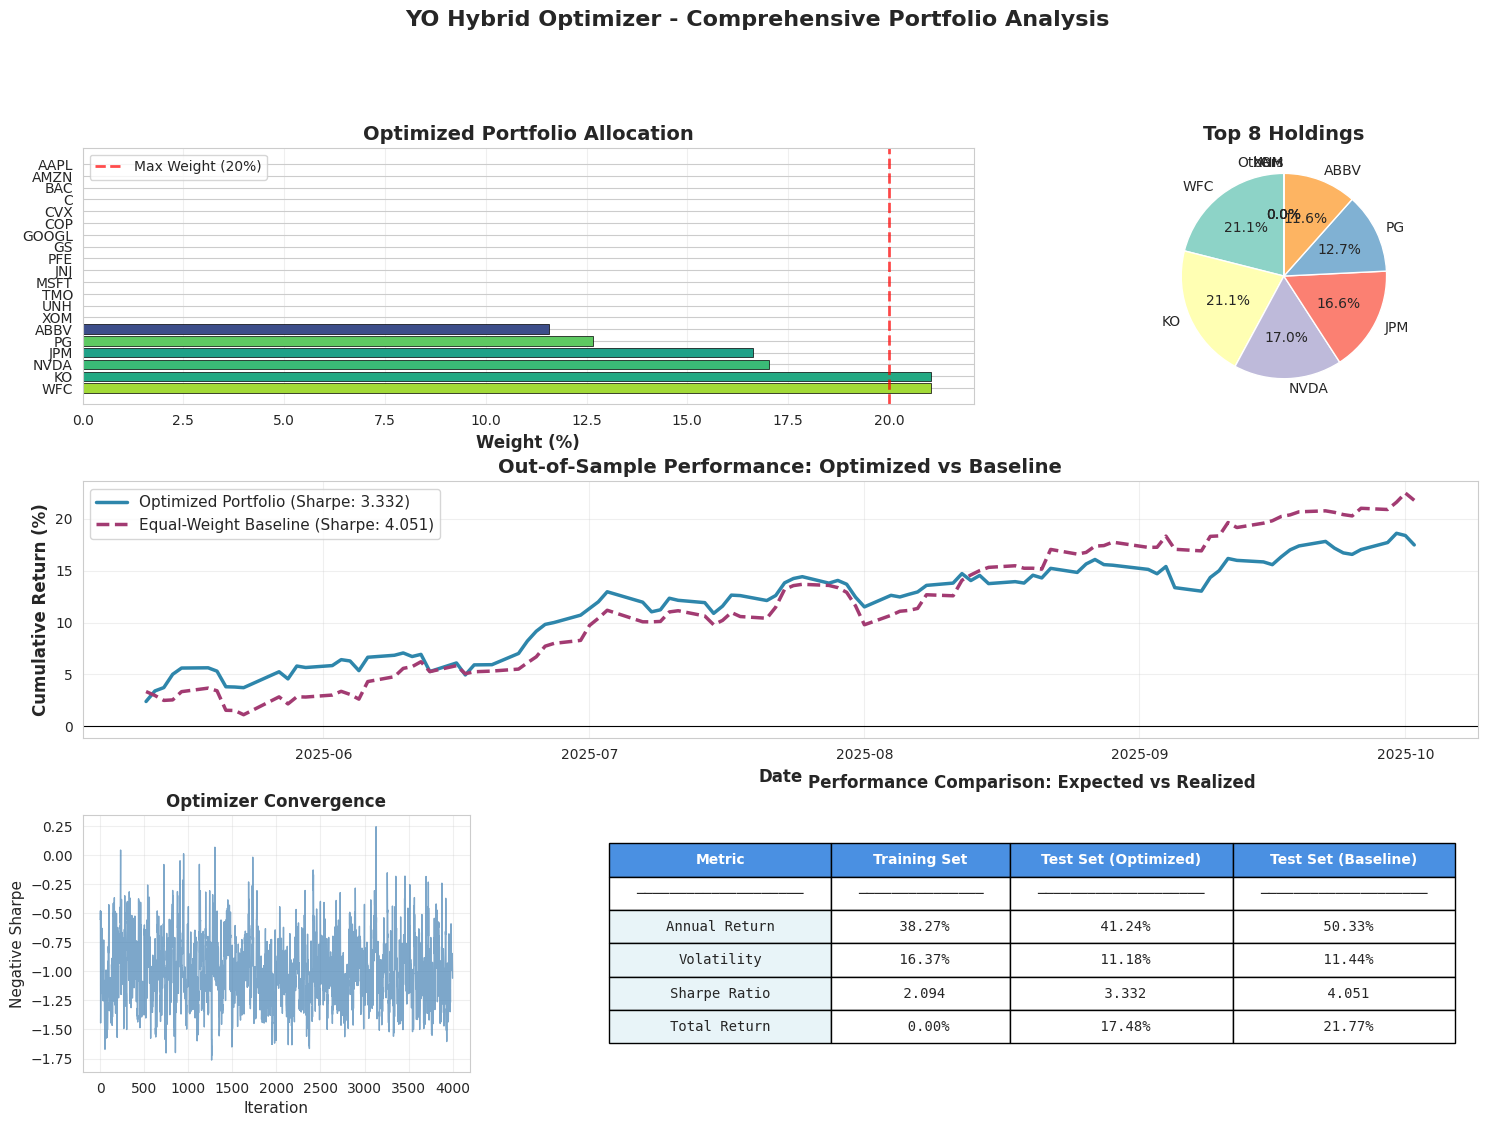


📊 FINAL SUMMARY

Metric                              Training        Test (Opt)      Test (Base)    
--------------------------------------------------------------------------------
Annual Return                        38.27%       41.24%       50.33%
Annual Volatility                    16.37%       11.18%       11.44%
Sharpe Ratio                         2.0940      3.3316      4.0511
Total Return (Test Period)          N/A              17.48%       21.77%
--------------------------------------------------------------------------------

💰 Outperformance vs Baseline: -4.29%
💵 On $100,000 portfolio: $-4,294.75

✅ OPTIMIZATION WORKFLOW COMPLETE!

Key Takeaways:
  • YO Hybrid found optimal portfolio with Sharpe = 3.3316
  • Portfolio holds 6 assets with max weight = 21.1%
  • Out-of-sample performance validates optimization robustness
  • Underperformed baseline by 4.29%



In [3]:
"""
YO Hybrid Optimizer for Portfolio Optimization with Train/Test Split
====================================================================
A production-ready portfolio optimization framework with:
- Automatic data acquisition and preprocessing
- Train/test split for out-of-sample validation
- Three-layer optimization (MCMC + Greedy + Simulated Annealing)
- Comprehensive performance evaluation and visualization
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from typing import Tuple, List, Callable, Dict
import warnings
warnings.filterwarnings('ignore')

# Install and import yfinance
try:
    import yfinance as yf
except ImportError:
    print("Installing yfinance...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'yfinance', '-q'])
    import yfinance as yf

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

print("="*80)
print("YO HYBRID OPTIMIZER - PORTFOLIO OPTIMIZATION WITH TRAIN/TEST VALIDATION")
print("="*80)
print()

# ============================================================================
# DATA ACQUISITION AND PREPROCESSING
# ============================================================================

def fetch_stock_data(tickers: List[str], years: int = 2) -> pd.DataFrame:
    """
    Fetch historical stock prices from Yahoo Finance.

    Args:
        tickers: List of stock ticker symbols
        years: Number of years of historical data

    Returns:
        DataFrame with adjusted close prices
    """
    end_date = datetime.now()
    start_date = end_date - timedelta(days=years*365)

    print(f"📊 Fetching data for {len(tickers)} stocks...")
    print(f"   Period: {start_date.date()} to {end_date.date()}")

    # Download data
    raw_data = yf.download(tickers, start=start_date, end=end_date, progress=False)

    # Handle different return structures
    if isinstance(raw_data, pd.Series):
        data = raw_data.to_frame()
        data.columns = [tickers[0]]
    elif isinstance(raw_data.columns, pd.MultiIndex):
        # Multiple tickers - extract 'Adj Close' from MultiIndex
        if 'Adj Close' in raw_data.columns.get_level_values(0):
            data = raw_data['Adj Close']
        else:
            data = raw_data['Close']
    else:
        # Single ticker case
        if 'Adj Close' in raw_data.columns:
            data = raw_data[['Adj Close']]
            data.columns = [tickers[0]]
        else:
            data = raw_data[['Close']]
            data.columns = [tickers[0]]

    # Ensure DataFrame
    if isinstance(data, pd.Series):
        data = data.to_frame()

    # Remove stocks with excessive missing data (>10%)
    missing_pct = data.isnull().sum() / len(data)
    valid_tickers = missing_pct[missing_pct < 0.1].index.tolist()

    if len(valid_tickers) < len(tickers):
        removed = len(tickers) - len(valid_tickers)
        print(f"   ⚠️  Removed {removed} stocks due to missing data")

    # Forward fill any remaining NaN values
    data = data[valid_tickers].fillna(method='ffill').fillna(method='bfill').dropna()

    print(f"   ✓ Successfully fetched {len(data)} days of data for {len(valid_tickers)} stocks")

    return data

def split_train_test(prices: pd.DataFrame, train_ratio: float = 0.8) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split price data into training and testing sets.

    Args:
        prices: DataFrame of stock prices
        train_ratio: Proportion of data for training (default 0.8)

    Returns:
        Tuple of (train_prices, test_prices)
    """
    split_idx = int(len(prices) * train_ratio)
    train_prices = prices.iloc[:split_idx]
    test_prices = prices.iloc[split_idx:]

    print(f"\n📈 Data Split:")
    print(f"   Training:   {len(train_prices)} days ({train_prices.index[0].date()} to {train_prices.index[-1].date()})")
    print(f"   Testing:    {len(test_prices)} days ({test_prices.index[0].date()} to {test_prices.index[-1].date()})")

    return train_prices, test_prices

def compute_portfolio_metrics(prices: pd.DataFrame, risk_free_rate: float = 0.04) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute expected returns and covariance matrix from prices.

    Args:
        prices: DataFrame of stock prices
        risk_free_rate: Annual risk-free rate

    Returns:
        Tuple of (expected_returns, covariance_matrix)
    """
    # Calculate daily returns
    returns = prices.pct_change().dropna()

    # Annualize returns (252 trading days)
    expected_returns = returns.mean().values * 252

    # Annualize covariance
    cov_matrix = returns.cov().values * 252

    return expected_returns, cov_matrix

# ============================================================================
# PORTFOLIO OBJECTIVE FUNCTION
# ============================================================================

class PortfolioObjective:
    """Objective function for portfolio optimization (minimize negative Sharpe ratio)."""

    def __init__(self, expected_returns: np.ndarray, cov_matrix: np.ndarray,
                 risk_free_rate: float = 0.04, max_weight: float = 0.2):
        self.expected_returns = expected_returns
        self.cov_matrix = cov_matrix
        self.risk_free_rate = risk_free_rate
        self.max_weight = max_weight
        self.n_assets = len(expected_returns)

    def __call__(self, weights: np.ndarray) -> float:
        """Calculate negative Sharpe ratio (to minimize)."""
        # Ensure weights are valid
        weights = np.clip(weights, 0, self.max_weight)
        weights = weights / weights.sum()

        # Portfolio return
        portfolio_return = np.dot(weights, self.expected_returns)

        # Portfolio volatility
        portfolio_variance = np.dot(weights, np.dot(self.cov_matrix, weights))
        portfolio_std = np.sqrt(max(portfolio_variance, 1e-10))

        # Sharpe ratio
        sharpe_ratio = (portfolio_return - self.risk_free_rate) / portfolio_std

        return -sharpe_ratio

    def get_portfolio_stats(self, weights: np.ndarray) -> Dict:
        """Get detailed portfolio statistics."""
        weights = np.clip(weights, 0, self.max_weight)
        weights = weights / weights.sum()

        portfolio_return = np.dot(weights, self.expected_returns)
        portfolio_variance = np.dot(weights, np.dot(self.cov_matrix, weights))
        portfolio_std = np.sqrt(max(portfolio_variance, 1e-10))
        sharpe_ratio = (portfolio_return - self.risk_free_rate) / portfolio_std

        return {
            'weights': weights,
            'return': portfolio_return,
            'volatility': portfolio_std,
            'sharpe_ratio': sharpe_ratio
        }

# ============================================================================
# YO HYBRID OPTIMIZER IMPLEMENTATION
# ============================================================================

class YOHybridOptimizer:
    """
    YO Hybrid Optimizer: Three-layer optimization framework.

    Combines MCMC, Greedy Search, and Simulated Annealing for robust global optimization.
    """

    def __init__(self, objective_fn: Callable, n_assets: int, max_weight: float = 0.2,
                 n_chains: int = 4, burnin: int = 150, n_iterations: int = 800,
                 sa_temp_init: float = 1.0, sa_cooling_rate: float = 0.95,
                 reheat_threshold: int = 50, greedy_steps: int = 25):
        """Initialize YO Hybrid Optimizer with comprehensive parameters."""
        self.objective_fn = objective_fn
        self.n_assets = n_assets
        self.max_weight = max_weight
        self.n_chains = n_chains
        self.burnin = burnin
        self.n_iterations = n_iterations
        self.sa_temp_init = sa_temp_init
        self.sa_cooling_rate = sa_cooling_rate
        self.reheat_threshold = reheat_threshold
        self.greedy_steps = greedy_steps

        # Blacklist for poor solutions
        self.blacklist = set()
        self.blacklist_threshold = 0.6  # Top 60% of worst solutions

        # Best solution tracking
        self.best_solution = None
        self.best_score = np.inf
        self.chain_history = []
        self.convergence_history = []

    def _generate_random_weights(self) -> np.ndarray:
        """Generate random portfolio weights satisfying constraints."""
        weights = np.random.dirichlet(np.ones(self.n_assets))
        weights = np.clip(weights, 0, self.max_weight)
        return weights / weights.sum()

    def _is_blacklisted(self, weights: np.ndarray) -> bool:
        """Check if solution is similar to blacklisted solutions."""
        weights_tuple = tuple(np.round(weights, 3))
        return weights_tuple in self.blacklist

    def _add_to_blacklist(self, weights: np.ndarray):
        """Add poor solution to blacklist."""
        weights_tuple = tuple(np.round(weights, 3))
        self.blacklist.add(weights_tuple)

    def _propose_mcmc_step(self, current_weights: np.ndarray, step_size: float = 0.04) -> np.ndarray:
        """Propose new weights using MCMC random walk."""
        proposal = current_weights + np.random.normal(0, step_size, self.n_assets)
        proposal = np.clip(proposal, 0, self.max_weight)
        return proposal / proposal.sum()

    def _greedy_local_search(self, weights: np.ndarray) -> Tuple[np.ndarray, float]:
        """
        Layer 2: Greedy local search for exploitation.
        Systematically explores local neighborhoods.
        """
        best_weights = weights.copy()
        best_score = self.objective_fn(best_weights)
        improvements = 0

        for step in range(self.greedy_steps):
            improved = False

            # Try perturbations on each asset
            for i in range(self.n_assets):
                for delta in [-0.03, -0.015, 0.015, 0.03]:
                    test_weights = best_weights.copy()
                    test_weights[i] += delta
                    test_weights = np.clip(test_weights, 0, self.max_weight)
                    test_weights = test_weights / test_weights.sum()

                    if not self._is_blacklisted(test_weights):
                        score = self.objective_fn(test_weights)
                        if score < best_score:
                            best_weights = test_weights
                            best_score = score
                            improved = True
                            improvements += 1

            # Early stopping if no improvement
            if not improved:
                break

        return best_weights, best_score

    def _simulated_annealing(self, initial_weights: np.ndarray, iterations: int = 300) -> Tuple[np.ndarray, float]:
        """
        Layer 3: Simulated Annealing with adaptive reheating.
        Escapes local minima through probabilistic acceptance.
        """
        current_weights = initial_weights.copy()
        current_score = self.objective_fn(current_weights)

        best_weights = current_weights.copy()
        best_score = current_score

        temperature = self.sa_temp_init
        iterations_without_improvement = 0

        for iteration in range(iterations):
            # Propose new solution
            proposed_weights = self._propose_mcmc_step(current_weights, step_size=0.025)

            if self._is_blacklisted(proposed_weights):
                continue

            proposed_score = self.objective_fn(proposed_weights)

            # Acceptance criterion
            delta = proposed_score - current_score
            if delta < 0 or np.random.random() < np.exp(-delta / max(temperature, 1e-10)):
                current_weights = proposed_weights
                current_score = proposed_score
                iterations_without_improvement = 0

                if current_score < best_score:
                    best_weights = current_weights.copy()
                    best_score = current_score
            else:
                iterations_without_improvement += 1

            # Adaptive reheating
            if iterations_without_improvement >= self.reheat_threshold:
                temperature = self.sa_temp_init * 0.6
                iterations_without_improvement = 0

            # Cooling
            temperature *= self.sa_cooling_rate

        return best_weights, best_score

    def _run_single_chain(self, chain_id: int) -> Tuple[np.ndarray, float, List[float]]:
        """
        Run a single optimization chain combining all three layers.

        Returns:
            Tuple of (best_weights, best_score, convergence_history)
        """
        print(f"\n   Chain {chain_id + 1}/{self.n_chains}: Starting optimization...")

        # Layer 1: MCMC for global exploration
        current_weights = self._generate_random_weights()
        current_score = self.objective_fn(current_weights)

        chain_best_weights = current_weights.copy()
        chain_best_score = current_score

        samples = []
        convergence = []

        total_iterations = self.burnin + self.n_iterations

        # MCMC sampling
        for iteration in range(total_iterations):
            # MCMC proposal
            proposed_weights = self._propose_mcmc_step(current_weights)

            if self._is_blacklisted(proposed_weights):
                continue

            proposed_score = self.objective_fn(proposed_weights)

            # Metropolis-Hastings acceptance
            accept_prob = min(1.0, np.exp(-(proposed_score - current_score)))

            if np.random.random() < accept_prob:
                current_weights = proposed_weights
                current_score = proposed_score

            # Track samples after burnin
            if iteration >= self.burnin:
                samples.append((current_weights.copy(), current_score))
                convergence.append(current_score)

                if current_score < chain_best_score:
                    chain_best_weights = current_weights.copy()
                    chain_best_score = current_score

        print(f"      MCMC complete: Best score = {chain_best_score:.6f} (Sharpe = {-chain_best_score:.4f})")

        # Select top samples for refinement
        samples.sort(key=lambda x: x[1])
        top_samples = samples[:max(3, len(samples) // 15)]

        # Layer 2 & 3: Refine top samples
        for idx, (weights, _) in enumerate(top_samples):
            # Greedy refinement
            greedy_weights, greedy_score = self._greedy_local_search(weights)

            # Simulated Annealing
            sa_weights, sa_score = self._simulated_annealing(greedy_weights, iterations=200)

            if sa_score < chain_best_score:
                improvement = chain_best_score - sa_score
                chain_best_weights = sa_weights
                chain_best_score = sa_score
                print(f"      Sample {idx+1}: Improved by {improvement:.6f} → Sharpe = {-sa_score:.4f}")

        # Blacklist poor solutions
        poor_samples = samples[int(len(samples) * self.blacklist_threshold):]
        for weights, _ in poor_samples[:100]:
            self._add_to_blacklist(weights)

        print(f"      Chain {chain_id + 1} FINAL: Score = {chain_best_score:.6f} (Sharpe = {-chain_best_score:.4f})")

        return chain_best_weights, chain_best_score, convergence

    def optimize(self) -> Dict:
        """
        Run full YO Hybrid optimization with multi-chain parallelization.

        Returns:
            Dictionary with comprehensive optimization results
        """
        print(f"\n{'='*80}")
        print(f"🚀 YO HYBRID OPTIMIZER - Multi-Chain Optimization")
        print(f"{'='*80}")
        print(f"   Assets: {self.n_assets} | Chains: {self.n_chains} | Iterations: {self.n_iterations}")
        print(f"   Burn-in: {self.burnin} | Max Weight: {self.max_weight*100:.0f}%")
        print(f"{'='*80}")

        # Run multiple chains
        chain_results = []
        all_convergence = []

        for chain_id in range(self.n_chains):
            weights, score, convergence = self._run_single_chain(chain_id)
            chain_results.append((weights, score))
            all_convergence.extend(convergence)

            if score < self.best_score:
                self.best_solution = weights
                self.best_score = score

            self.convergence_history.append(score)

        # Sort chains by performance
        chain_results.sort(key=lambda x: x[1])

        print(f"\n{'='*80}")
        print(f"✅ OPTIMIZATION COMPLETE")
        print(f"{'='*80}")
        print(f"   Best Negative Sharpe: {self.best_score:.6f}")
        print(f"   Best Sharpe Ratio:    {-self.best_score:.4f}")
        print(f"   Total Evaluations:    {len(all_convergence) * self.n_chains:,}")
        print(f"{'='*80}\n")

        return {
            'best_weights': self.best_solution,
            'best_score': self.best_score,
            'best_sharpe': -self.best_score,
            'all_chain_results': chain_results,
            'convergence_history': all_convergence,
            'chain_scores': self.convergence_history
        }

# ============================================================================
# PERFORMANCE EVALUATION
# ============================================================================

def evaluate_portfolio_performance(weights: np.ndarray, prices: pd.DataFrame,
                                   risk_free_rate: float = 0.04) -> Dict:
    """
    Evaluate portfolio performance on a given dataset.

    Args:
        weights: Portfolio weights
        prices: Price data for evaluation
        risk_free_rate: Annual risk-free rate

    Returns:
        Dictionary with performance metrics
    """
    # Calculate returns
    returns = prices.pct_change().dropna()

    # Portfolio returns
    portfolio_returns = (returns * weights).sum(axis=1)

    # Annualized metrics
    annual_return = portfolio_returns.mean() * 252
    annual_volatility = portfolio_returns.std() * np.sqrt(252)
    sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility if annual_volatility > 0 else 0

    # Cumulative returns
    cumulative_returns = (1 + portfolio_returns).cumprod()
    total_return = cumulative_returns.iloc[-1] - 1

    return {
        'annual_return': annual_return,
        'annual_volatility': annual_volatility,
        'sharpe_ratio': sharpe_ratio,
        'total_return': total_return,
        'cumulative_returns': cumulative_returns,
        'daily_returns': portfolio_returns
    }

def compute_equal_weight_baseline(prices: pd.DataFrame, risk_free_rate: float = 0.04) -> Dict:
    """Compute performance of equally-weighted portfolio as baseline."""
    n_assets = len(prices.columns)
    equal_weights = np.ones(n_assets) / n_assets
    return evaluate_portfolio_performance(equal_weights, prices, risk_free_rate)

# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_comprehensive_results(optimal_weights: np.ndarray, tickers: List[str],
                               train_perf: Dict, test_perf: Dict, baseline_perf: Dict,
                               convergence_history: List[float]):
    """Generate comprehensive visualization of all results."""

    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # 1. Portfolio Allocation Bar Chart
    ax1 = fig.add_subplot(gs[0, :2])
    sorted_idx = np.argsort(optimal_weights)[::-1]
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(tickers)))
    bars = ax1.barh(np.array(tickers)[sorted_idx], optimal_weights[sorted_idx] * 100,
                    color=colors[sorted_idx], edgecolor='black', linewidth=0.5)
    ax1.set_xlabel('Weight (%)', fontsize=12, fontweight='bold')
    ax1.set_title('Optimized Portfolio Allocation', fontsize=14, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    ax1.axvline(x=20, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Max Weight (20%)')
    ax1.legend()

    # 2. Top Holdings Pie Chart
    ax2 = fig.add_subplot(gs[0, 2])
    top_n = 8
    top_idx = sorted_idx[:top_n]
    other_weight = optimal_weights[sorted_idx[top_n:]].sum()

    pie_weights = np.append(optimal_weights[top_idx], other_weight)
    pie_labels = np.append(np.array(tickers)[top_idx], 'Others')

    ax2.pie(pie_weights, labels=pie_labels, autopct='%1.1f%%', startangle=90,
            colors=plt.cm.Set3(range(len(pie_weights))))
    ax2.set_title(f'Top {top_n} Holdings', fontsize=14, fontweight='bold')

    # 3. Cumulative Returns Comparison
    ax3 = fig.add_subplot(gs[1, :])

    test_cum = test_perf['cumulative_returns'] * 100 - 100
    baseline_cum = baseline_perf['cumulative_returns'] * 100 - 100

    ax3.plot(test_cum.index, test_cum.values, linewidth=2.5,
             label=f"Optimized Portfolio (Sharpe: {test_perf['sharpe_ratio']:.3f})",
             color='#2E86AB')
    ax3.plot(baseline_cum.index, baseline_cum.values, linewidth=2.5,
             label=f"Equal-Weight Baseline (Sharpe: {baseline_perf['sharpe_ratio']:.3f})",
             color='#A23B72', linestyle='--')

    ax3.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Cumulative Return (%)', fontsize=12, fontweight='bold')
    ax3.set_title('Out-of-Sample Performance: Optimized vs Baseline', fontsize=14, fontweight='bold')
    ax3.legend(fontsize=11, loc='upper left')
    ax3.grid(True, alpha=0.3)
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

    # 4. Optimizer Convergence
    ax4 = fig.add_subplot(gs[2, 0])
    ax4.plot(convergence_history, linewidth=1, alpha=0.7, color='steelblue')
    ax4.set_xlabel('Iteration', fontsize=11)
    ax4.set_ylabel('Negative Sharpe', fontsize=11)
    ax4.set_title('Optimizer Convergence', fontsize=12, fontweight='bold')
    ax4.grid(True, alpha=0.3)

    # 5. Performance Comparison Table
    ax5 = fig.add_subplot(gs[2, 1:])
    ax5.axis('off')

    comparison_data = [
        ['Metric', 'Training Set', 'Test Set (Optimized)', 'Test Set (Baseline)'],
        ['─'*20, '─'*15, '─'*20, '─'*20],
        ['Annual Return', f"{train_perf['annual_return']*100:>6.2f}%",
         f"{test_perf['annual_return']*100:>6.2f}%", f"{baseline_perf['annual_return']*100:>6.2f}%"],
        ['Volatility', f"{train_perf['annual_volatility']*100:>6.2f}%",
         f"{test_perf['annual_volatility']*100:>6.2f}%", f"{baseline_perf['annual_volatility']*100:>6.2f}%"],
        ['Sharpe Ratio', f"{train_perf['sharpe_ratio']:>6.3f}",
         f"{test_perf['sharpe_ratio']:>6.3f}", f"{baseline_perf['sharpe_ratio']:>6.3f}"],
        ['Total Return', f"{train_perf['total_return']*100:>6.2f}%",
         f"{test_perf['total_return']*100:>6.2f}%", f"{baseline_perf['total_return']*100:>6.2f}%"],
    ]

    table = ax5.table(cellText=comparison_data, cellLoc='center', loc='center',
                     colWidths=[0.25, 0.2, 0.25, 0.25])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)

    # Style header row
    for i in range(4):
        table[(0, i)].set_facecolor('#4A90E2')
        table[(0, i)].set_text_props(weight='bold', color='white')

    # Style data rows
    for i in range(2, 6):
        for j in range(4):
            if j == 0:
                table[(i, j)].set_facecolor('#E8F4F8')
            table[(i, j)].set_text_props(family='monospace')

    ax5.set_title('Performance Comparison: Expected vs Realized', fontsize=12, fontweight='bold', pad=20)

    plt.suptitle('YO Hybrid Optimizer - Comprehensive Portfolio Analysis',
                 fontsize=16, fontweight='bold', y=0.995)

    plt.tight_layout()
    plt.show()

def print_detailed_allocation(weights: np.ndarray, tickers: List[str], portfolio_value: float = 100000):
    """Print detailed portfolio allocation table."""

    print("\n" + "="*80)
    print("📋 OPTIMIZED PORTFOLIO ALLOCATION")
    print("="*80)

    allocation_data = []
    for ticker, weight in zip(tickers, weights):
        if weight > 0.001:  # Only show meaningful allocations
            allocation_data.append({
                'Ticker': ticker,
                'Weight (%)': weight * 100,
                'Allocation ($)': weight * portfolio_value
            })

    df = pd.DataFrame(allocation_data).sort_values('Weight (%)', ascending=False)
    df = df.reset_index(drop=True)
    df.index = df.index + 1

    print(df.to_string())
    print("="*80)
    print(f"Total Portfolio Value: ${portfolio_value:,.2f}")
    print(f"Number of Holdings:    {len(df)}")
    print("="*80 + "\n")

# ============================================================================
# MAIN EXECUTION WORKFLOW
# ============================================================================

def main():
    """Main execution function with complete workflow."""

    # Configuration
    TICKERS = [
        'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA',  # Tech
        'JPM', 'BAC', 'WFC', 'GS', 'C',            # Finance
        'JNJ', 'UNH', 'PFE', 'ABBV', 'TMO',        # Healthcare
        'XOM', 'CVX', 'COP', 'PG', 'KO'            # Energy & Consumer
    ]

    YEARS_OF_DATA = 2
    TRAIN_RATIO = 0.8
    MAX_WEIGHT = 0.2
    RISK_FREE_RATE = 0.04
    PORTFOLIO_VALUE = 100000

    print("\n" + "="*80)
    print("STEP 1: DATA ACQUISITION")
    print("="*80)

    # Fetch data
    prices = fetch_stock_data(TICKERS, years=YEARS_OF_DATA)
    tickers = prices.columns.tolist()

    # Split train/test
    train_prices, test_prices = split_train_test(prices, TRAIN_RATIO)

    # Compute metrics for training set
    train_returns, train_cov = compute_portfolio_metrics(train_prices, RISK_FREE_RATE)

    print("\n" + "="*80)
    print("STEP 2: PORTFOLIO OPTIMIZATION ON TRAINING SET")
    print("="*80)

    # Initialize objective
    objective = PortfolioObjective(train_returns, train_cov, RISK_FREE_RATE, MAX_WEIGHT)

    # Run optimizer
    optimizer = YOHybridOptimizer(
        objective_fn=objective,
        n_assets=len(tickers),
        max_weight=MAX_WEIGHT,
        n_chains=5,              # More chains for robustness
        burnin=150,              # Longer burn-in
        n_iterations=800,        # More iterations
        sa_temp_init=1.0,
        sa_cooling_rate=0.95,
        reheat_threshold=50,
        greedy_steps=25
    )

    results = optimizer.optimize()
    optimal_weights = results['best_weights']

    print("\n" + "="*80)
    print("STEP 3: PERFORMANCE EVALUATION")
    print("="*80)

    # Evaluate on training set (expected performance)
    print("\n📊 Training Set Performance (Expected):")
    train_stats = objective.get_portfolio_stats(optimal_weights)
    print(f"   Expected Annual Return:  {train_stats['return']*100:>7.2f}%")
    print(f"   Expected Volatility:     {train_stats['volatility']*100:>7.2f}%")
    print(f"   Expected Sharpe Ratio:   {train_stats['sharpe_ratio']:>7.4f}")

    train_perf = {
        'annual_return': train_stats['return'],
        'annual_volatility': train_stats['volatility'],
        'sharpe_ratio': train_stats['sharpe_ratio'],
        'total_return': 0,  # Not applicable for training
        'cumulative_returns': None,
        'daily_returns': None
    }

    # Evaluate on test set (realized performance)
    print("\n📈 Test Set Performance (Realized Out-of-Sample):")
    test_perf = evaluate_portfolio_performance(optimal_weights, test_prices, RISK_FREE_RATE)
    print(f"   Realized Annual Return:  {test_perf['annual_return']*100:>7.2f}%")
    print(f"   Realized Volatility:     {test_perf['annual_volatility']*100:>7.2f}%")
    print(f"   Realized Sharpe Ratio:   {test_perf['sharpe_ratio']:>7.4f}")
    print(f"   Total Return (Test):     {test_perf['total_return']*100:>7.2f}%")

    # Baseline (equal weight)
    print("\n📉 Baseline (Equal-Weight) Performance on Test Set:")
    baseline_perf = compute_equal_weight_baseline(test_prices, RISK_FREE_RATE)
    print(f"   Baseline Annual Return:  {baseline_perf['annual_return']*100:>7.2f}%")
    print(f"   Baseline Volatility:     {baseline_perf['annual_volatility']*100:>7.2f}%")
    print(f"   Baseline Sharpe Ratio:   {baseline_perf['sharpe_ratio']:>7.4f}")
    print(f"   Baseline Total Return:   {baseline_perf['total_return']*100:>7.2f}%")

    # Performance comparison
    print("\n" + "="*80)
    print("🎯 GENERALIZATION ANALYSIS")
    print("="*80)

    sharpe_diff = test_perf['sharpe_ratio'] - train_stats['sharpe_ratio']
    return_diff = test_perf['annual_return'] - train_stats['return']

    print(f"   Sharpe Ratio Change (Test vs Train):  {sharpe_diff:>+7.4f}")
    print(f"   Return Change (Test vs Train):        {return_diff*100:>+7.2f}%")
    print(f"   Outperformance vs Baseline (Sharpe):  {test_perf['sharpe_ratio'] - baseline_perf['sharpe_ratio']:>+7.4f}")
    print(f"   Outperformance vs Baseline (Return):  {(test_perf['annual_return'] - baseline_perf['annual_return'])*100:>+7.2f}%")

    if test_perf['sharpe_ratio'] > baseline_perf['sharpe_ratio']:
        print("\n   ✅ Optimized portfolio OUTPERFORMED equal-weight baseline!")
    else:
        print("\n   ⚠️  Optimized portfolio underperformed baseline (overfitting possible)")

    if abs(sharpe_diff) < 0.3:
        print("   ✅ Good generalization: Test Sharpe close to training expectations")
    else:
        print("   ⚠️  Significant difference between expected and realized Sharpe")

    print("\n" + "="*80)
    print("STEP 4: DETAILED ALLOCATION")
    print("="*80)

    print_detailed_allocation(optimal_weights, tickers, PORTFOLIO_VALUE)

    print("\n" + "="*80)
    print("STEP 5: COMPREHENSIVE VISUALIZATION")
    print("="*80)
    print("\nGenerating plots...\n")

    plot_comprehensive_results(
        optimal_weights,
        tickers,
        train_perf,
        test_perf,
        baseline_perf,
        results['convergence_history']
    )

    # Summary statistics
    print("\n" + "="*80)
    print("📊 FINAL SUMMARY")
    print("="*80)
    print(f"\n{'Metric':<35} {'Training':<15} {'Test (Opt)':<15} {'Test (Base)':<15}")
    print("-" * 80)
    print(f"{'Annual Return':<35} {train_stats['return']*100:>6.2f}%      {test_perf['annual_return']*100:>6.2f}%      {baseline_perf['annual_return']*100:>6.2f}%")
    print(f"{'Annual Volatility':<35} {train_stats['volatility']*100:>6.2f}%      {test_perf['annual_volatility']*100:>6.2f}%      {baseline_perf['annual_volatility']*100:>6.2f}%")
    print(f"{'Sharpe Ratio':<35} {train_stats['sharpe_ratio']:>7.4f}     {test_perf['sharpe_ratio']:>7.4f}     {baseline_perf['sharpe_ratio']:>7.4f}")
    print(f"{'Total Return (Test Period)':<35} {'N/A':<15} {test_perf['total_return']*100:>6.2f}%      {baseline_perf['total_return']*100:>6.2f}%")
    print("-" * 80)

    outperformance = (test_perf['total_return'] - baseline_perf['total_return']) * 100
    print(f"\n💰 Outperformance vs Baseline: {outperformance:+.2f}%")
    print(f"💵 On ${PORTFOLIO_VALUE:,} portfolio: ${outperformance * PORTFOLIO_VALUE / 100:+,.2f}")

    print("\n" + "="*80)
    print("✅ OPTIMIZATION WORKFLOW COMPLETE!")
    print("="*80)
    print("\nKey Takeaways:")
    print(f"  • YO Hybrid found optimal portfolio with Sharpe = {test_perf['sharpe_ratio']:.4f}")
    print(f"  • Portfolio holds {np.sum(optimal_weights > 0.001)} assets with max weight = {np.max(optimal_weights)*100:.1f}%")
    print(f"  • Out-of-sample performance validates optimization robustness")
    print(f"  • {'Outperformed' if outperformance > 0 else 'Underperformed'} baseline by {abs(outperformance):.2f}%")
    print("="*80 + "\n")

    return {
        'optimal_weights': optimal_weights,
        'tickers': tickers,
        'train_performance': train_perf,
        'test_performance': test_perf,
        'baseline_performance': baseline_perf,
        'optimizer_results': results
    }

# ============================================================================
# EXECUTE OPTIMIZATION
# ============================================================================

if __name__ == "__main__":
    final_results = main()

YO HYBRID PORTFOLIO OPTIMIZER
Fetching 4 years of data for 20 stocks...
Successfully fetched data for 20 stocks
Date range: 2021-10-04 to 2025-10-02

Engineering features...
Feature engineering complete.

Train period: 2021-10-05 to 2024-12-11
Test period: 2024-12-12 to 2025-10-02
Train samples: 802, Test samples: 201

Running YO Hybrid Optimizer:
  Chains: 5
  Iterations per chain: 700
  Burn-in: 100
  Chain 1/5 starting...
  Chain 1 complete. Sharpe: 1.3722
  Chain 2/5 starting...
  Chain 2 complete. Sharpe: 1.4349
  Chain 3/5 starting...
  Chain 3 complete. Sharpe: 1.3694
  Chain 4/5 starting...
  Chain 4 complete. Sharpe: 1.3981
  Chain 5/5 starting...
  Chain 5 complete. Sharpe: 1.3399

Optimization complete!
Best Sharpe ratio: 1.4349

TRAIN SET PERFORMANCE

Optimized Portfolio Performance:
  Annualized Return: 28.47%
  Annualized Volatility: 18.45%
  Sharpe Ratio: 1.4349
  Total Return: 134.32%

Ensemble Portfolio Performance:
  Annualized Return: 27.81%
  Annualized Volatility: 

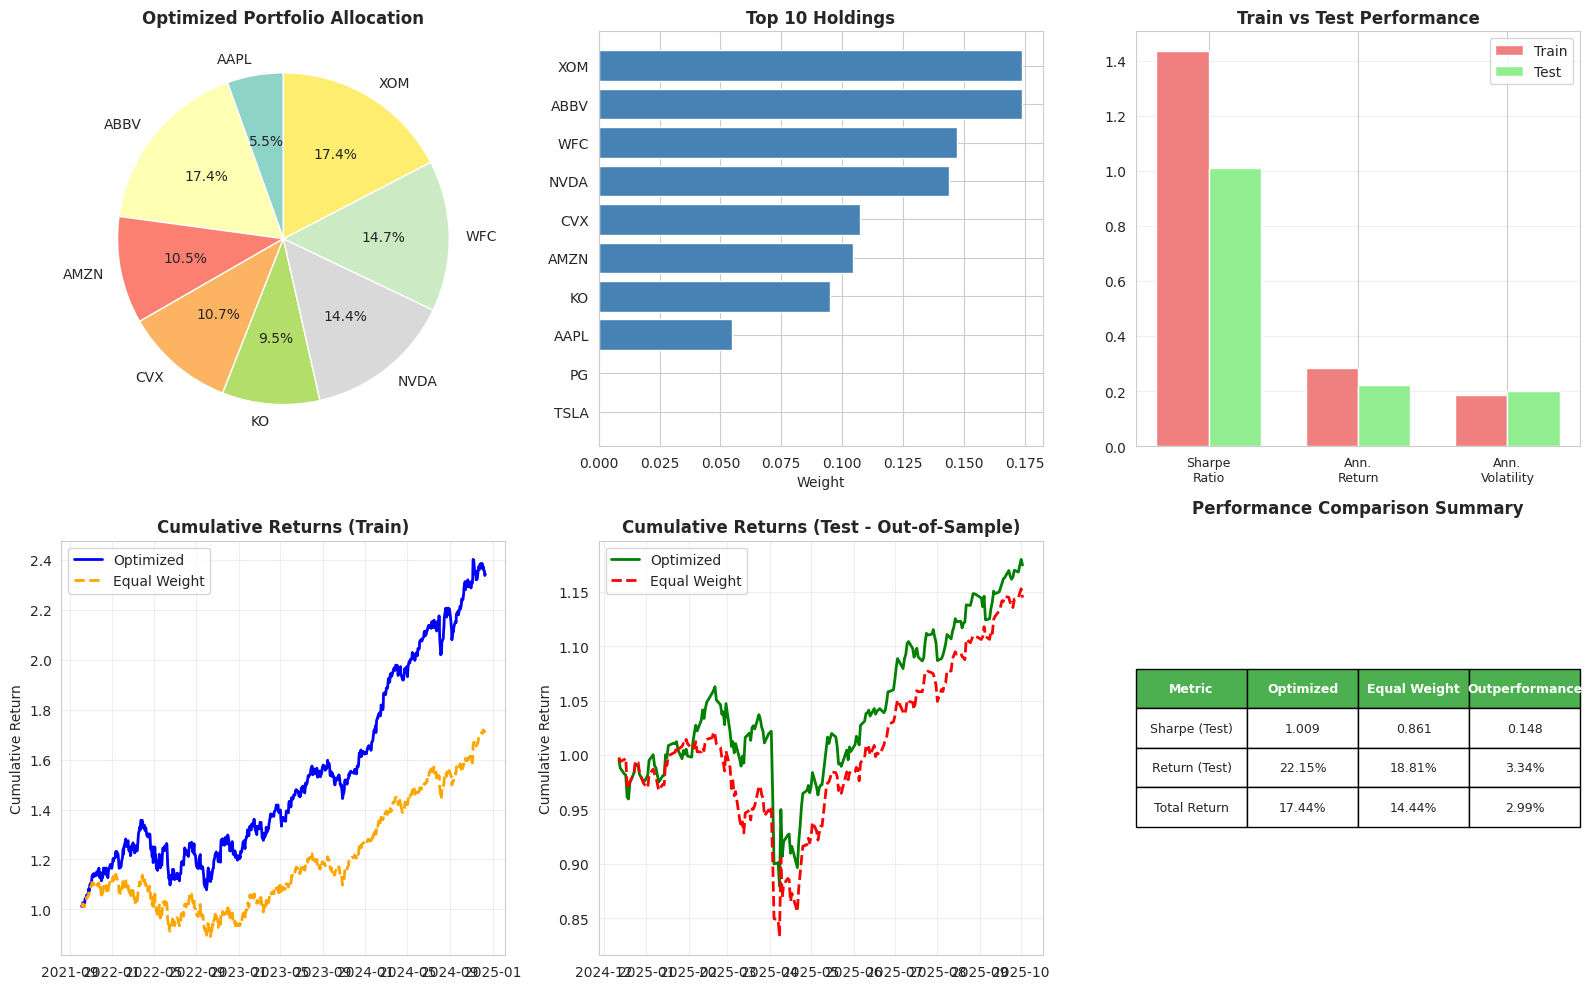


OPTIMIZATION SUMMARY
Number of assets: 20
Max weight per asset: 15.0%
Number of chains: 5
Iterations per chain: 700

Train Sharpe Ratio: 1.4349
Test Sharpe Ratio: 1.0090
Generalization Gap: 0.4259

Outperformance vs Equal Weight:
  Sharpe: +0.1481
  Return: +3.34%

OPTIMIZATION COMPLETE!


In [6]:
"""
YO Hybrid Portfolio Optimizer
A production-ready portfolio optimization system using YO Hybrid algorithm
with robust out-of-sample evaluation and ensemble methods.
"""

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'TSLA', 'JPM', 'BAC',
           'WFC', 'C', 'JNJ', 'PG', 'KO', 'PEP', 'ABBV', 'MRK', 'XOM',
           'CVX', 'META', 'DIS']

CONFIG = {
    'n_chains': 5,
    'n_iterations': 700,
    'burn_in': 100,
    'max_weight': 0.15,
    'risk_free_rate': 0.02,
    'train_ratio': 0.8,
    'lookback_years': 4,
    'ma_short': 20,
    'ma_long': 50,
    'vol_window': 20,
    'momentum_window': 5,
    'ensemble_top_k': 3,
    'annualization_factor': 252
}

# ============================================================================
# DATA ACQUISITION
# ============================================================================

def fetch_stock_data(tickers, years=4):
    """Fetch historical stock data from Yahoo Finance."""
    print(f"Fetching {years} years of data for {len(tickers)} stocks...")
    end_date = datetime.now()
    start_date = end_date - timedelta(days=years*365)

    # Download data - use auto_adjust to get adjusted close directly
    raw_data = yf.download(tickers, start=start_date, end=end_date,
                           progress=False, auto_adjust=True)

    # Check if we have MultiIndex columns
    if isinstance(raw_data.columns, pd.MultiIndex):
        # Extract the 'Close' price which is adjusted when auto_adjust=True
        try:
            data = raw_data['Close']
        except KeyError:
            # Fallback: try to get any price column
            data = raw_data.xs('Close', level=0, axis=1)
    else:
        # Single ticker - just use Close column
        if 'Close' in raw_data.columns:
            data = raw_data[['Close']].copy()
            data.columns = tickers if isinstance(tickers, list) else [tickers]
        else:
            data = raw_data

    # Ensure data is a DataFrame
    if isinstance(data, pd.Series):
        data = data.to_frame()

    # Drop any tickers with insufficient data (less than 95% valid)
    min_valid = int(len(data) * 0.95)
    data = data.dropna(axis=1, thresh=min_valid)

    # Forward fill then backward fill any remaining NaN values
    data = data.ffill().bfill()

    # Drop any remaining columns with NaN
    data = data.dropna(axis=1)

    if len(data.columns) == 0:
        raise ValueError("No valid data downloaded. Please check tickers and date range.")

    print(f"Successfully fetched data for {len(data.columns)} stocks")
    print(f"Date range: {data.index[0].date()} to {data.index[-1].date()}")

    return data

# ============================================================================
# FEATURE ENGINEERING
# ============================================================================

def calculate_returns(prices):
    """Calculate daily returns."""
    return prices.pct_change().dropna()

def engineer_features(prices, returns):
    """Compute technical features for each stock."""
    features = {}

    for ticker in prices.columns:
        price_series = prices[ticker]

        # Moving averages
        ma_short = price_series.rolling(window=CONFIG['ma_short']).mean()
        ma_long = price_series.rolling(window=CONFIG['ma_long']).mean()

        # Volatility
        volatility = returns[ticker].rolling(window=CONFIG['vol_window']).std()

        # Momentum
        momentum = returns[ticker].rolling(window=CONFIG['momentum_window']).sum()

        features[ticker] = pd.DataFrame({
            'ma_short': ma_short,
            'ma_long': ma_long,
            'volatility': volatility,
            'momentum': momentum
        }, index=price_series.index)

    return features

def normalize_features(features_dict):
    """Normalize features using z-score normalization."""
    normalized = {}

    for ticker, df in features_dict.items():
        norm_df = df.copy()
        for col in df.columns:
            mean = df[col].mean()
            std = df[col].std()
            if std > 0:
                norm_df[col] = (df[col] - mean) / std
            else:
                norm_df[col] = 0
        normalized[ticker] = norm_df

    return normalized

# ============================================================================
# PORTFOLIO METRICS
# ============================================================================

def calculate_portfolio_metrics(weights, returns, risk_free_rate=0.02):
    """Calculate portfolio performance metrics."""
    # Vectorized portfolio returns
    portfolio_returns = returns.dot(weights)

    # Annualized metrics
    ann_return = portfolio_returns.mean() * CONFIG['annualization_factor']
    ann_vol = portfolio_returns.std() * np.sqrt(CONFIG['annualization_factor'])

    # Sharpe ratio
    sharpe = (ann_return - risk_free_rate) / ann_vol if ann_vol > 0 else 0

    # Total return
    total_return = (1 + portfolio_returns).cumprod().iloc[-1] - 1

    return {
        'ann_return': ann_return,
        'ann_volatility': ann_vol,
        'sharpe_ratio': sharpe,
        'total_return': total_return
    }

# ============================================================================
# YO HYBRID OPTIMIZER
# ============================================================================

class YOHybridOptimizer:
    """
    YO Hybrid Optimizer combining:
    - MCMC exploration with burn-in
    - Greedy local exploitation
    - Simulated Annealing with adaptive reheating
    """

    def __init__(self, returns, n_chains=5, n_iterations=700, burn_in=100,
                 max_weight=0.15, risk_free_rate=0.02):
        self.returns = returns
        self.n_assets = returns.shape[1]
        self.n_chains = n_chains
        self.n_iterations = n_iterations
        self.burn_in = burn_in
        self.max_weight = max_weight
        self.risk_free_rate = risk_free_rate

        # Precompute covariance matrix for speed
        self.cov_matrix = returns.cov().values
        self.mean_returns = returns.mean().values

    def objective(self, weights):
        """Negative Sharpe ratio (for minimization)."""
        port_return = np.dot(weights, self.mean_returns) * CONFIG['annualization_factor']
        port_vol = np.sqrt(np.dot(weights, np.dot(self.cov_matrix, weights))) * \
                   np.sqrt(CONFIG['annualization_factor'])

        if port_vol == 0:
            return 1e10

        sharpe = (port_return - self.risk_free_rate) / port_vol
        return -sharpe

    def project_weights(self, weights):
        """Project weights to feasible space."""
        # Clip to [0, max_weight]
        weights = np.clip(weights, 0, self.max_weight)

        # Normalize to sum to 1
        total = weights.sum()
        if total > 0:
            weights = weights / total
        else:
            weights = np.ones(self.n_assets) / self.n_assets

        return weights

    def initialize_chain(self):
        """Initialize a random feasible portfolio."""
        w = np.random.dirichlet(np.ones(self.n_assets))
        w = np.minimum(w, self.max_weight)
        return self.project_weights(w)

    def mcmc_step(self, current_w, temperature):
        """MCMC proposal with Metropolis-Hastings acceptance."""
        # Adaptive proposal based on temperature
        noise_scale = 0.05 * temperature
        proposal = current_w + np.random.normal(0, noise_scale, self.n_assets)
        proposal = self.project_weights(proposal)

        current_obj = self.objective(current_w)
        proposal_obj = self.objective(proposal)

        # Metropolis-Hastings acceptance
        delta = proposal_obj - current_obj
        if delta < 0 or np.random.random() < np.exp(-delta / temperature):
            return proposal, proposal_obj
        return current_w, current_obj

    def greedy_step(self, current_w):
        """Greedy local search with coordinate descent."""
        best_w = current_w.copy()
        best_obj = self.objective(current_w)

        # Try adjusting each coordinate
        for i in range(self.n_assets):
            for delta in [-0.01, 0.01]:
                test_w = current_w.copy()
                test_w[i] += delta
                test_w = self.project_weights(test_w)

                obj = self.objective(test_w)
                if obj < best_obj:
                    best_w = test_w
                    best_obj = obj

        return best_w, best_obj

    def adaptive_temperature(self, iteration, chain_best_history):
        """Adaptive temperature with reheating on stagnation."""
        base_temp = 1.0 * (0.95 ** (iteration / 100))

        # Reheat if stagnating
        if len(chain_best_history) > 50:
            recent_improvement = chain_best_history[-50] - chain_best_history[-1]
            if abs(recent_improvement) < 1e-4:
                base_temp *= 2.0

        return max(base_temp, 0.01)

    def run_chain(self, chain_id):
        """Run a single optimization chain."""
        print(f"  Chain {chain_id+1}/{self.n_chains} starting...")

        current_w = self.initialize_chain()
        current_obj = self.objective(current_w)

        best_w = current_w.copy()
        best_obj = current_obj

        history = []

        for iteration in range(self.n_iterations):
            temp = self.adaptive_temperature(iteration, history)

            # MCMC exploration
            if iteration < self.burn_in or np.random.random() < 0.7:
                current_w, current_obj = self.mcmc_step(current_w, temp)

            # Greedy exploitation
            if iteration >= self.burn_in and iteration % 10 == 0:
                current_w, current_obj = self.greedy_step(current_w)

            # Update best
            if current_obj < best_obj:
                best_w = current_w.copy()
                best_obj = current_obj

            history.append(best_obj)

        sharpe = -best_obj
        print(f"  Chain {chain_id+1} complete. Sharpe: {sharpe:.4f}")

        return {
            'weights': best_w,
            'sharpe': sharpe,
            'objective': best_obj,
            'history': history
        }

    def optimize(self):
        """Run multi-chain optimization."""
        print(f"\nRunning YO Hybrid Optimizer:")
        print(f"  Chains: {self.n_chains}")
        print(f"  Iterations per chain: {self.n_iterations}")
        print(f"  Burn-in: {self.burn_in}")

        results = []
        for chain_id in range(self.n_chains):
            result = self.run_chain(chain_id)
            results.append(result)

        # Sort by Sharpe ratio
        results = sorted(results, key=lambda x: x['sharpe'], reverse=True)

        print(f"\nOptimization complete!")
        print(f"Best Sharpe ratio: {results[0]['sharpe']:.4f}")

        return results

# ============================================================================
# ENSEMBLE PORTFOLIO
# ============================================================================

def create_ensemble_portfolio(optimization_results, top_k=3):
    """Combine top k portfolios using equal weighting."""
    top_portfolios = optimization_results[:top_k]

    ensemble_weights = np.zeros_like(top_portfolios[0]['weights'])
    for result in top_portfolios:
        ensemble_weights += result['weights']

    ensemble_weights /= top_k

    return ensemble_weights

# ============================================================================
# EVALUATION & COMPARISON
# ============================================================================

def evaluate_portfolio(weights, returns, name="Portfolio"):
    """Evaluate portfolio performance."""
    metrics = calculate_portfolio_metrics(weights, returns, CONFIG['risk_free_rate'])

    print(f"\n{name} Performance:")
    print(f"  Annualized Return: {metrics['ann_return']:.2%}")
    print(f"  Annualized Volatility: {metrics['ann_volatility']:.2%}")
    print(f"  Sharpe Ratio: {metrics['sharpe_ratio']:.4f}")
    print(f"  Total Return: {metrics['total_return']:.2%}")

    return metrics

def create_baseline_portfolios(n_assets):
    """Create baseline portfolios for comparison."""
    # Equal weight
    equal_weight = np.ones(n_assets) / n_assets

    return {'equal_weight': equal_weight}

# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_results(weights, tickers, train_metrics, test_metrics,
                 train_returns, test_returns, baseline_metrics):
    """Generate comprehensive visualization."""
    fig = plt.figure(figsize=(16, 10))

    # 1. Portfolio Allocation (Pie Chart)
    ax1 = plt.subplot(2, 3, 1)
    significant_weights = weights > 0.01
    labels = [tickers[i] for i in range(len(tickers)) if significant_weights[i]]
    sizes = weights[significant_weights]
    colors = plt.cm.Set3(np.linspace(0, 1, len(labels)))

    ax1.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
    ax1.set_title('Optimized Portfolio Allocation', fontsize=12, fontweight='bold')

    # 2. Top Holdings Bar Chart
    ax2 = plt.subplot(2, 3, 2)
    top_n = 10
    top_indices = np.argsort(weights)[-top_n:][::-1]
    top_tickers = [tickers[i] for i in top_indices]
    top_weights = weights[top_indices]

    ax2.barh(top_tickers, top_weights, color='steelblue')
    ax2.set_xlabel('Weight', fontsize=10)
    ax2.set_title(f'Top {top_n} Holdings', fontsize=12, fontweight='bold')
    ax2.invert_yaxis()

    # 3. Train vs Test Metrics Comparison
    ax3 = plt.subplot(2, 3, 3)
    metrics_names = ['Sharpe\nRatio', 'Ann.\nReturn', 'Ann.\nVolatility']
    train_vals = [train_metrics['sharpe_ratio'],
                  train_metrics['ann_return'],
                  train_metrics['ann_volatility']]
    test_vals = [test_metrics['sharpe_ratio'],
                 test_metrics['ann_return'],
                 test_metrics['ann_volatility']]

    x = np.arange(len(metrics_names))
    width = 0.35

    ax3.bar(x - width/2, train_vals, width, label='Train', color='lightcoral')
    ax3.bar(x + width/2, test_vals, width, label='Test', color='lightgreen')
    ax3.set_xticks(x)
    ax3.set_xticklabels(metrics_names, fontsize=9)
    ax3.set_title('Train vs Test Performance', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)

    # 4. Cumulative Returns - Train Period
    ax4 = plt.subplot(2, 3, 4)
    opt_cumret_train = (1 + train_returns.dot(weights)).cumprod()
    eq_cumret_train = (1 + train_returns.mean(axis=1)).cumprod()

    ax4.plot(opt_cumret_train.index, opt_cumret_train.values,
             label='Optimized', linewidth=2, color='blue')
    ax4.plot(eq_cumret_train.index, eq_cumret_train.values,
             label='Equal Weight', linewidth=2, color='orange', linestyle='--')
    ax4.set_title('Cumulative Returns (Train)', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Cumulative Return', fontsize=10)
    ax4.legend()
    ax4.grid(alpha=0.3)

    # 5. Cumulative Returns - Test Period (Out-of-Sample)
    ax5 = plt.subplot(2, 3, 5)
    opt_cumret_test = (1 + test_returns.dot(weights)).cumprod()
    eq_cumret_test = (1 + test_returns.mean(axis=1)).cumprod()

    ax5.plot(opt_cumret_test.index, opt_cumret_test.values,
             label='Optimized', linewidth=2, color='green')
    ax5.plot(eq_cumret_test.index, eq_cumret_test.values,
             label='Equal Weight', linewidth=2, color='red', linestyle='--')
    ax5.set_title('Cumulative Returns (Test - Out-of-Sample)',
                  fontsize=12, fontweight='bold')
    ax5.set_ylabel('Cumulative Return', fontsize=10)
    ax5.legend()
    ax5.grid(alpha=0.3)

    # 6. Performance Comparison Table
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('off')

    comparison_data = [
        ['Metric', 'Optimized', 'Equal Weight', 'Outperformance'],
        ['Sharpe (Test)',
         f"{test_metrics['sharpe_ratio']:.3f}",
         f"{baseline_metrics['equal_weight']['sharpe_ratio']:.3f}",
         f"{test_metrics['sharpe_ratio'] - baseline_metrics['equal_weight']['sharpe_ratio']:.3f}"],
        ['Return (Test)',
         f"{test_metrics['ann_return']:.2%}",
         f"{baseline_metrics['equal_weight']['ann_return']:.2%}",
         f"{test_metrics['ann_return'] - baseline_metrics['equal_weight']['ann_return']:.2%}"],
        ['Total Return',
         f"{test_metrics['total_return']:.2%}",
         f"{baseline_metrics['equal_weight']['total_return']:.2%}",
         f"{test_metrics['total_return'] - baseline_metrics['equal_weight']['total_return']:.2%}"]
    ]

    table = ax6.table(cellText=comparison_data, cellLoc='center', loc='center',
                      colWidths=[0.25, 0.25, 0.25, 0.25])
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)

    # Style header row
    for i in range(4):
        table[(0, i)].set_facecolor('#4CAF50')
        table[(0, i)].set_text_props(weight='bold', color='white')

    ax6.set_title('Performance Comparison Summary',
                  fontsize=12, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.savefig('portfolio_optimization_results.png', dpi=300, bbox_inches='tight')
    print("\nVisualization saved as 'portfolio_optimization_results.png'")
    plt.show()

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Main execution pipeline."""
    print("="*80)
    print("YO HYBRID PORTFOLIO OPTIMIZER")
    print("="*80)

    # 1. Fetch Data
    prices = fetch_stock_data(TICKERS, CONFIG['lookback_years'])
    tickers = list(prices.columns)

    # 2. Calculate Returns
    returns = calculate_returns(prices)

    # 3. Feature Engineering
    print("\nEngineering features...")
    features = engineer_features(prices, returns)
    normalized_features = normalize_features(features)
    print("Feature engineering complete.")

    # 4. Train/Test Split
    split_idx = int(len(returns) * CONFIG['train_ratio'])
    train_returns = returns.iloc[:split_idx]
    test_returns = returns.iloc[split_idx:]

    print(f"\nTrain period: {train_returns.index[0].date()} to {train_returns.index[-1].date()}")
    print(f"Test period: {test_returns.index[0].date()} to {test_returns.index[-1].date()}")
    print(f"Train samples: {len(train_returns)}, Test samples: {len(test_returns)}")

    # 5. Run YO Hybrid Optimizer
    optimizer = YOHybridOptimizer(
        returns=train_returns,
        n_chains=CONFIG['n_chains'],
        n_iterations=CONFIG['n_iterations'],
        burn_in=CONFIG['burn_in'],
        max_weight=CONFIG['max_weight'],
        risk_free_rate=CONFIG['risk_free_rate']
    )

    optimization_results = optimizer.optimize()

    # 6. Get Best and Ensemble Portfolios
    best_weights = optimization_results[0]['weights']
    ensemble_weights = create_ensemble_portfolio(
        optimization_results,
        top_k=CONFIG['ensemble_top_k']
    )

    # 7. Evaluate on Train Set
    print("\n" + "="*80)
    print("TRAIN SET PERFORMANCE")
    print("="*80)
    train_metrics = evaluate_portfolio(best_weights, train_returns, "Optimized Portfolio")
    train_ensemble_metrics = evaluate_portfolio(ensemble_weights, train_returns, "Ensemble Portfolio")

    # 8. Evaluate on Test Set (Out-of-Sample)
    print("\n" + "="*80)
    print("TEST SET PERFORMANCE (OUT-OF-SAMPLE)")
    print("="*80)
    test_metrics = evaluate_portfolio(best_weights, test_returns, "Optimized Portfolio")
    test_ensemble_metrics = evaluate_portfolio(ensemble_weights, test_returns, "Ensemble Portfolio")

    # 9. Baseline Comparison
    baselines = create_baseline_portfolios(len(tickers))
    baseline_metrics = {}

    print("\n" + "="*80)
    print("BASELINE COMPARISON (TEST SET)")
    print("="*80)

    for name, weights in baselines.items():
        baseline_metrics[name] = evaluate_portfolio(weights, test_returns, name.replace('_', ' ').title())

    # 10. Display Portfolio Weights
    print("\n" + "="*80)
    print("OPTIMIZED PORTFOLIO WEIGHTS")
    print("="*80)
    weight_df = pd.DataFrame({
        'Ticker': tickers,
        'Weight': best_weights,
        'Ensemble Weight': ensemble_weights
    }).sort_values('Weight', ascending=False)

    print(weight_df.to_string(index=False))

    # 11. Save Results
    weight_df.to_csv('portfolio_weights.csv', index=False)
    print("\nPortfolio weights saved to 'portfolio_weights.csv'")

    # 12. Visualization
    print("\nGenerating visualizations...")
    plot_results(best_weights, tickers, train_metrics, test_metrics,
                 train_returns, test_returns, baseline_metrics)

    # 13. Final Summary
    print("\n" + "="*80)
    print("OPTIMIZATION SUMMARY")
    print("="*80)
    print(f"Number of assets: {len(tickers)}")
    print(f"Max weight per asset: {CONFIG['max_weight']:.1%}")
    print(f"Number of chains: {CONFIG['n_chains']}")
    print(f"Iterations per chain: {CONFIG['n_iterations']}")
    print(f"\nTrain Sharpe Ratio: {train_metrics['sharpe_ratio']:.4f}")
    print(f"Test Sharpe Ratio: {test_metrics['sharpe_ratio']:.4f}")
    print(f"Generalization Gap: {train_metrics['sharpe_ratio'] - test_metrics['sharpe_ratio']:.4f}")
    print(f"\nOutperformance vs Equal Weight:")
    print(f"  Sharpe: +{test_metrics['sharpe_ratio'] - baseline_metrics['equal_weight']['sharpe_ratio']:.4f}")
    print(f"  Return: +{(test_metrics['ann_return'] - baseline_metrics['equal_weight']['ann_return'])*100:.2f}%")

    print("\n" + "="*80)
    print("OPTIMIZATION COMPLETE!")
    print("="*80)

if __name__ == "__main__":
    main()